# Optimisation de la Gestion des Déchets

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msn
from tabulate import tabulate

In [86]:
data = pd.read_csv("Data/waste_dataset_for_analysis.csv")
data.head(7)

,Area,Population_Density,Household_Size,Waste_Generation,Collection_Frequency,Recycling_Rate,Collection_Point_Location,Road_Network_Score,Disposal_Site_Distance,Pollution_Level,Top 1 Waste_Type,Top 2 Waste_Type,Top 3 Waste_Type
0,Quartier_1,8270.0,6,3.39,6,0.35,53,0.98,2.13,0.72,Paper,Plastic,Glass
1,Quartier_2,1860.0,4,2.31,2,0.74,40,0.49,17.95,0.31,Paper,Metal,Glass
2,Quartier_3,6390.0,5,1.20,2,0.69,53,0.72,4.62,0.47,Glass,Organic,Paper
3,Quartier_4,6191.0,6,0.56,3,0.85,74,0.82,2.38,0.20,Glass,Metal,Organic
4,Quartier_5,6734.0,5,2.11,1,0.62,52,0.72,2.46,0.48,Organic,Plastic,Glass
5,Quartier_6,7265.0,5,3.35,5,0.17,81,0.54,4.60,0.14,Organic,Glass,Plastic
6,Quartier_7,NaN,4,2.85,4,NaN,3,0.48,13.81,0.24,Metal,Paper,Plastic


In [87]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154 entries, 0 to 153
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Area                       154 non-null    object 
 1   Population_Density         143 non-null    float64
 2   Household_Size             154 non-null    int64  
 3   Waste_Generation           154 non-null    float64
 4   Collection_Frequency       154 non-null    int64  
 5   Recycling_Rate             143 non-null    float64
 6   Collection_Point_Location  154 non-null    int64  
 7   Road_Network_Score         154 non-null    float64
 8   Disposal_Site_Distance     154 non-null    float64
 9   Pollution_Level            154 non-null    float64
 10  Top 1 Waste_Type           154 non-null    object 
 11  Top 2 Waste_Type           154 non-null    object 
 12  Top 3 Waste_Type           154 non-null    object 
dtypes: float64(6), int64(3), object(4)
memory usage: 1

In [88]:
data.describe()

,Population_Density,Household_Size,Waste_Generation,Collection_Frequency,Recycling_Rate,Collection_Point_Location,Road_Network_Score,Disposal_Site_Distance,Pollution_Level
count,143.000000,154.000000,154.000000,154.000000,143.000000,154.000000,154.000000,154.000000,154.000000
mean,5856.916084,4.785714,4.519585,3.688312,0.546224,55.402597,0.519935,14.634561,0.365065
std,2639.684727,1.664565,10.116414,1.802393,0.259101,27.926261,0.269860,40.766003,0.262970
min,1064.000000,2.000000,0.540000,1.000000,0.010000,1.000000,0.000000,0.260000,0.000000
25%,3590.000000,3.000000,1.527500,2.000000,0.335000,31.500000,0.295000,2.612500,0.150000
50%,6390.000000,5.000000,2.710000,4.000000,0.570000,55.000000,0.550000,4.535000,0.335000
75%,8153.500000,6.000000,4.037500,5.000000,0.740000,78.750000,0.740000,12.467500,0.500000
max,9996.000000,7.000000,77.935890,6.000000,1.000000,100.000000,1.000000,319.546830,1.000000


# Prétraitement des données

In [89]:
# Verifions les doublons
data.duplicated().sum()

11

In [90]:
# Supprimons les doublons
data = data.drop_duplicates()

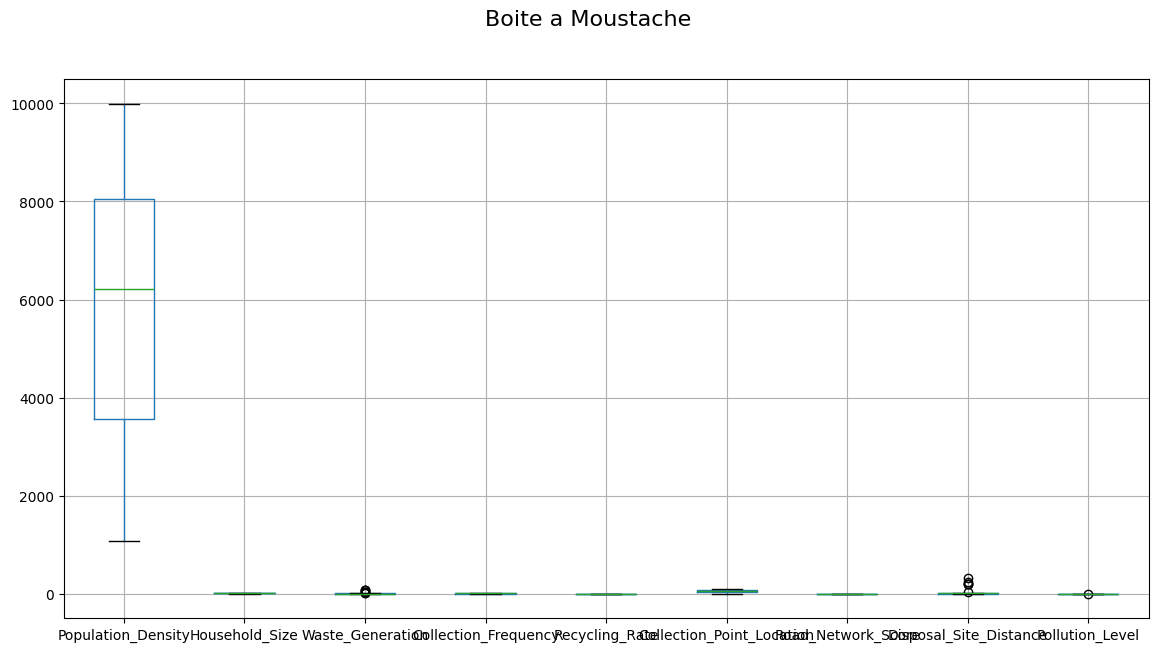

In [91]:
# Boite a moustache
data.boxplot(column=['Population_Density', 'Household_Size', 'Waste_Generation','Collection_Frequency', 'Recycling_Rate','Collection_Point_Location','Road_Network_Score', 'Disposal_Site_Distance', 'Pollution_Level'], figsize=(14, 7))
plt.suptitle('Boite a Moustache', fontsize=16)
plt.show()

In [92]:
# Traiter les valeurs aberantes // Waste_Generation
Q1 = data['Waste_Generation'].quantile(0.25)
Q3 = data['Waste_Generation'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
data = data[(data['Waste_Generation'] >=lower_bound) & (data['Waste_Generation'] <= upper_bound)]

In [93]:
# Traiter les valeurs aberantes // Disposal_Site_Distance
Q1 = data['Disposal_Site_Distance'].quantile(0.25)
Q3 = data['Disposal_Site_Distance'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
data = data[(data['Disposal_Site_Distance'] >=lower_bound) & (data['Disposal_Site_Distance'] <= upper_bound)]

In [94]:
# Valeurs manquantes
data.isna().sum()

Area                          0
Population_Density           10
Household_Size                0
Waste_Generation              0
Collection_Frequency          0
Recycling_Rate               10
Collection_Point_Location     0
Road_Network_Score            0
Disposal_Site_Distance        0
Pollution_Level               0
Top 1 Waste_Type              0
Top 2 Waste_Type              0
Top 3 Waste_Type              0
dtype: int64

In [95]:
# Suppression des valeurs manquantes
data['Population_Density'] = data['Population_Density'].fillna(data['Population_Density'].mean())
data['Recycling_Rate'] = data['Recycling_Rate'].fillna(data['Recycling_Rate'].mean())
#data.dropna()

In [96]:
data.isna().sum()

Area                         0
Population_Density           0
Household_Size               0
Waste_Generation             0
Collection_Frequency         0
Recycling_Rate               0
Collection_Point_Location    0
Road_Network_Score           0
Disposal_Site_Distance       0
Pollution_Level              0
Top 1 Waste_Type             0
Top 2 Waste_Type             0
Top 3 Waste_Type             0
dtype: int64

In [97]:
# Changer les valeurs de nom unknow des colonnes Top 1 Top 2 et Top 3 waste_Type par autres
data['Top 1 Waste_Type'] = data['Top 1 Waste_Type'].replace('Unknown', 'Autres')
data['Top 2 Waste_Type'] = data['Top 2 Waste_Type'].replace('Unknown', 'Autres')
data.head(15)

,Area,Population_Density,Household_Size,Waste_Generation,Collection_Frequency,Recycling_Rate,Collection_Point_Location,Road_Network_Score,Disposal_Site_Distance,Pollution_Level,Top 1 Waste_Type,Top 2 Waste_Type,Top 3 Waste_Type
0,Quartier_1,8270.000000,6,3.39,6,0.350000,53,0.98,2.13,0.72,Paper,Plastic,Glass
1,Quartier_2,1860.000000,4,2.31,2,0.740000,40,0.49,17.95,0.31,Paper,Metal,Glass
2,Quartier_3,6390.000000,5,1.20,2,0.690000,53,0.72,4.62,0.47,Glass,Organic,Paper
3,Quartier_4,6191.000000,6,0.56,3,0.850000,74,0.82,2.38,0.20,Glass,Metal,Organic
4,Quartier_5,6734.000000,5,2.11,1,0.620000,52,0.72,2.46,0.48,Organic,Plastic,Glass
5,Quartier_6,7265.000000,5,3.35,5,0.170000,81,0.54,4.60,0.14,Organic,Glass,Plastic
6,Quartier_7,5807.968254,4,2.85,4,0.548333,3,0.48,13.81,0.24,Metal,Paper,Plastic
7,Quartier_8,5426.000000,6,2.88,2,0.630000,76,0.84,0.26,0.13,Glass,Paper,Organic
8,Quartier_9,6578.000000,7,2.79,1,0.700000,78,0.21,18.69,0.27,Plastic,Organic,Glass
9,Quartier_10,9322.000000,7,3.74,6,0.290000,81,0.97,1.32,0.16,Paper,Metal,Organic


# Facteurs associés aux taux de recyclage

Facteurs associés aux taux de recyclage:
Nous devons comprendre les divers facteurs qui 
influencent les taux de recyclage dans différentes zones. En identifiant ces facteurs, nous 
visons à mettre en œuvre des stratégies ciblées pour améliorer les taux de recyclage et 
encourager des pratiques plus respectueuses de l'environnement parmi les résidents

In [98]:
from scipy.stats import pearsonr, spearmanr
# Suppression des colonnes
data1 = data.drop(['Area', 'Top 1 Waste_Type', 'Top 2 Waste_Type', 'Top 3 Waste_Type'], axis=1)
Y1 = data['Recycling_Rate']

# Coefficient de correlation de Pearson
headers = ['variables', 'Coefficient de correlation de Pearson']
data_correlation = []
for col in data1.columns:
    if col != 'Recycling_Rate':
        r_pearson, p_value = pearsonr(data1[col], Y1)
        data_correlation.append([f'{col} et Recycling_Rate:', r_pearson])

print(tabulate(data_correlation, headers=headers))

variables                                       Coefficient de correlation de Pearson
--------------------------------------------  ---------------------------------------
Population_Density et Recycling_Rate:                                       -0.700722
Household_Size et Recycling_Rate:                                           -0.466364
Waste_Generation et Recycling_Rate:                                         -0.673471
Collection_Frequency et Recycling_Rate:                                     -0.642098
Collection_Point_Location et Recycling_Rate:                                -0.481425
Road_Network_Score et Recycling_Rate:                                       -0.101435
Disposal_Site_Distance et Recycling_Rate:                                    0.118557
Pollution_Level et Recycling_Rate:                                          -0.524876


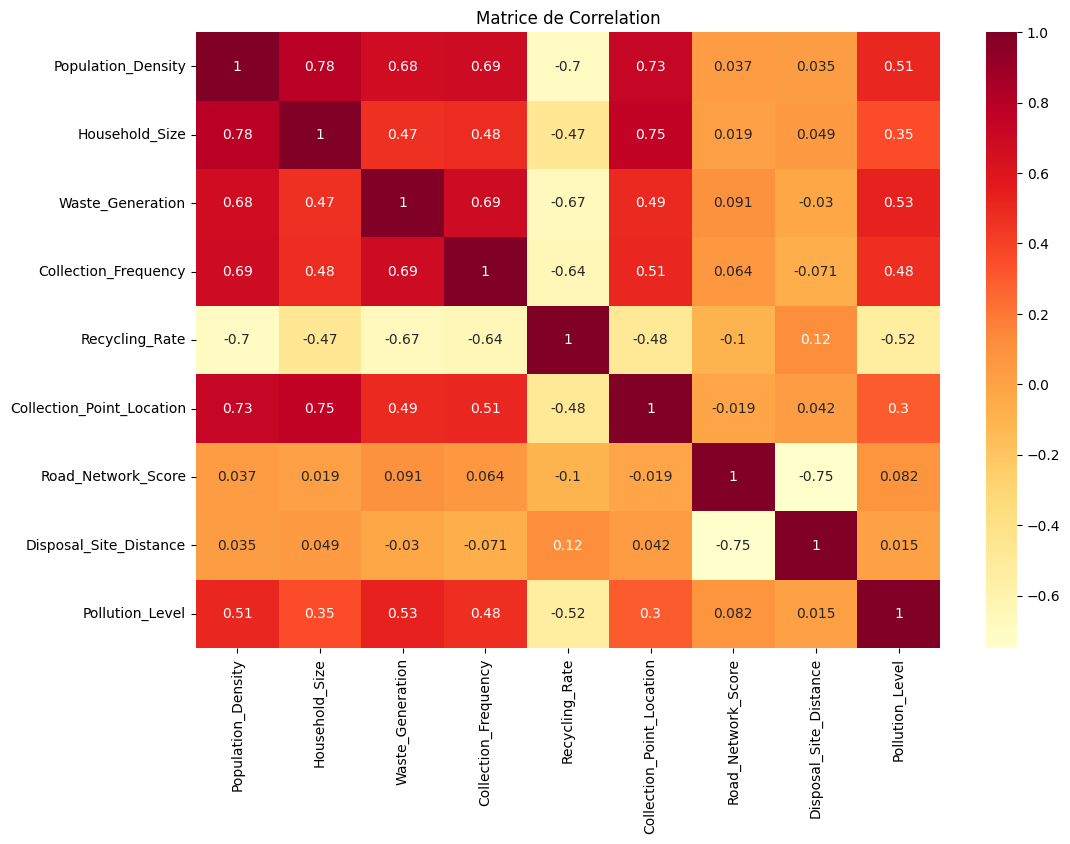

In [99]:
# Matrice de correlation
plt.figure(figsize=(12,8))
sns.heatmap(data1.corr(), annot=True, cmap='YlOrRd')
plt.title('Matrice de Correlation')
plt.show()

In [100]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

X = data[['Population_Density', 'Collection_Frequency', 'Pollution_Level', 'Collection_Point_Location']]
Y = data['Recycling_Rate']
# Diviser le jeu de donnees
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
# Entrainer le modele de regression lineaire
modele = LinearRegression()
modele.fit(X_train, Y_train)
# prediction
y_predict = modele.predict(X_test)
y_predict

array([0.78410281, 0.75467804, 0.34664917, 0.82025945, 0.65699984,
       0.3816157 , 0.29084322, 0.64038867, 0.33352533, 0.19606853,
       0.71841638, 0.36161081, 0.69110475, 0.2252792 , 0.69318644,
       0.64159841, 0.82452924, 0.5528423 , 0.58354105, 0.28636607,
       0.76010561, 0.58389839, 0.62751516, 0.82801261, 0.56556753,
       0.76539523, 0.56189593, 0.21064467])

In [101]:
# Evaluation des performances du modele
r2 = r2_score(Y_test, y_predict)
mse = mean_squared_error(Y_test, y_predict)
print(f"coefficient de determination: {r2}")
print(f"somme moyenne des carrees des erreurs: {mse}")

coefficient de determination: 0.46459338815351736
somme moyenne des carrees des erreurs: 0.028927897451272378


# Optimisation  des  itinéraires  de  collecte  des  déchets

Optimisation  des  itinéraires  de  collecte  des  déchets  Nos itinéraires de collecte des 
déchets actuels sont inefficaces, entraînant une consommation de carburant élevée et des 
coûts  opérationnels  accrus.  Nous  devons  optimiser  ces  itinéraires  pour  minimiser  la 
consommation de carburant et réduire le temps passé sur la route. En regroupant les zones 
ayant  des  schémas  de  production  de  déchets  similaires,  nous  pouvons  élaborer  des 
horaires de collecte plus efficaces, ce qui permettra d'économiser des coûts et d'améliorer la 
qualité du service.

In [102]:
from sklearn.cluster import KMeans
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics import precision_score, confusion_matrix

# selection des variables pertinentes pour notre modele
selector = VarianceThreshold(threshold=0.08)
selector.fit_transform(data1)
selector.get_support()

array([ True,  True,  True,  True, False,  True, False,  True, False])

In [103]:
features = data1[['Population_Density', 'Household_Size', 'Waste_Generation', 'Collection_Frequency', 'Collection_Point_Location', 'Disposal_Site_Distance']]
# Normaliser les variables
scaler = StandardScaler()
data1_norm = scaler.fit_transform(features)
# Calcul de la variance de chaque variable
data1_norm.var(axis=0)

array([1., 1., 1., 1., 1., 1.])

# Algorithme K-Means

L'objectif de la méthode du coude est de trouver le nombre optimal de cluster (K) en traçant la variance expliquée par rapport au nombre de clusters et en identifiant le "coude" ou le taux de réduction de la variance commence à se stabiliser. Il aide à déterminer un numéro de cluster approprie pour les K-Means et les algorithmes similaires.

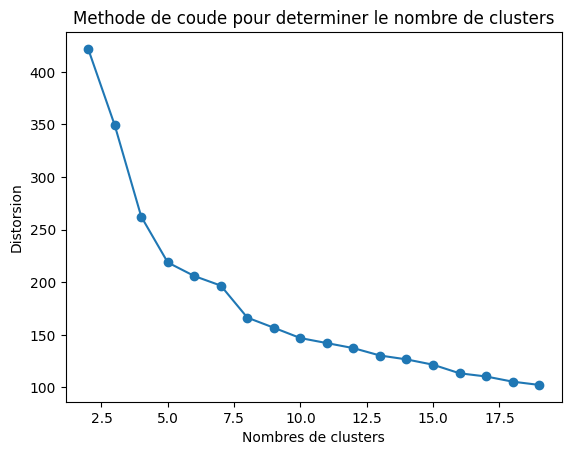

In [104]:
# Determinons le nombre optimum de clusters avec la methode de coude
silhouettes = []
inertie = []
for i in range(2, 20):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(data1_norm)
    inertie.append(km.inertia_)
    silhouettes.append(silhouette_score(data1_norm, km.labels_))
plt.plot(range(2, 20), inertie, marker='o')
plt.xlabel("Nombres de clusters")
plt.ylabel("Distorsion")
plt.title("Methode de coude pour determiner le nombre de clusters")
plt.show()

Le score de silhouette est calculé pour chaque point de données en mesurant la similarité avec son propre cluster par rapport aux clusters voisins les plus proches. Il varie de -1 (mauvaise adéquation) a +1 (bonne adéquation), un score élevé indique des clusters bien définis. Cela permet de déterminer le nombre optimal de clusters dans un ensemble de données.

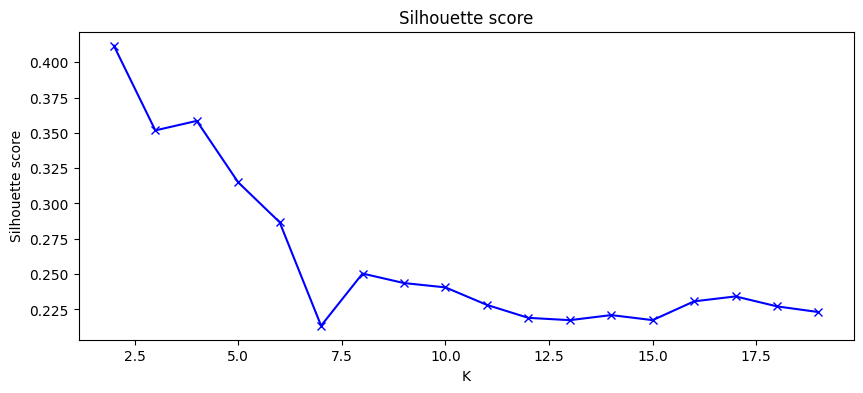

In [105]:
# Graphique du score silhouette score
plt.figure(figsize=(10, 4))
plt.plot(range(2, 20), silhouettes, 'bx-')
plt.xlabel('K')
plt.ylabel("Silhouette score")
plt.title("Silhouette score")
plt.show()

In [106]:
# Creeons notre modele avec k=6
optimal_cluster = 2
model = KMeans(n_clusters=optimal_cluster)
labels = model.fit_predict(data1_norm)
data['cluster'] = labels
data

,Area,Population_Density,Household_Size,Waste_Generation,Collection_Frequency,Recycling_Rate,Collection_Point_Location,Road_Network_Score,Disposal_Site_Distance,Pollution_Level,Top 1 Waste_Type,Top 2 Waste_Type,Top 3 Waste_Type,cluster
0,Quartier_1,8270.0,6,3.39,6,0.35,53,0.98,2.13,0.72,Paper,Plastic,Glass,0
1,Quartier_2,1860.0,4,2.31,2,0.74,40,0.49,17.95,0.31,Paper,Metal,Glass,1
2,Quartier_3,6390.0,5,1.20,2,0.69,53,0.72,4.62,0.47,Glass,Organic,Paper,1
3,Quartier_4,6191.0,6,0.56,3,0.85,74,0.82,2.38,0.20,Glass,Metal,Organic,1
4,Quartier_5,6734.0,5,2.11,1,0.62,52,0.72,2.46,0.48,Organic,Plastic,Glass,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,Quartier_139,8392.0,5,3.19,5,0.27,77,0.74,3.88,0.53,Glass,Metal,Plastic,0
139,Quartier_140,2306.0,3,2.21,1,0.73,11,0.21,6.02,0.13,Paper,Metal,Organic,1
140,Quartier_141,7776.0,5,3.14,6,0.29,53,0.79,4.20,0.52,Metal,Organic,Glass,0
141,Quartier_142,6864.0,7,1.30,4,0.70,64,0.60,2.24,0.25,Plastic,Organic,Paper,0


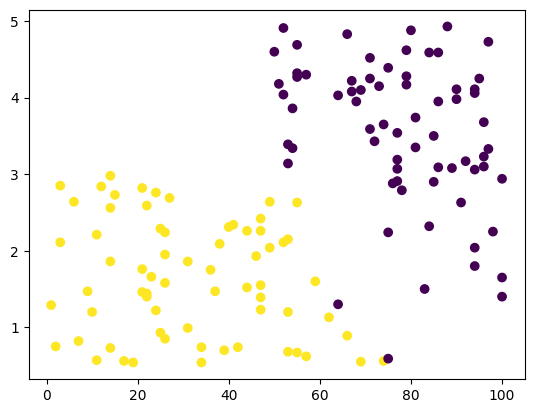

In [107]:
plt.scatter(x=features['Collection_Point_Location'], y=features['Waste_Generation'], c=labels)

In [108]:

for cluster in range(optimal_cluster):
    print(f"Cluster {cluster}:")
    print(data[data['cluster'] == cluster].drop(['Area', 'Top 1 Waste_Type', 'Top 2 Waste_Type', 'Top 3 Waste_Type'], axis=1).describe())
    

Cluster 0:
       Population_Density  Household_Size  Waste_Generation  \
count           69.000000       69.000000         69.000000   
mean          7827.142167        6.028986          3.532609   
std           1309.348310        0.873987          0.975404   
min           5426.000000        5.000000          0.590000   
25%           6915.000000        5.000000          3.070000   
50%           7949.000000        6.000000          3.680000   
75%           8869.000000        7.000000          4.250000   
max           9996.000000        7.000000          4.930000   

       Collection_Frequency  Recycling_Rate  Collection_Point_Location  \
count             69.000000       69.000000                  69.000000   
mean               4.869565        0.389565                  77.797101   
std                1.381741        0.222922                  14.808165   
min                1.000000        0.010000                  50.000000   
25%                5.000000        0.230000        

In [109]:

for cluster in range(optimal_cluster):
    zones_cluster = data[data['cluster'] == cluster]['Area'].tolist()
    print(f"Zones appartenent au cluster {cluster}: {', '.join(zones_cluster)}")

Zones appartenent au cluster 0: Quartier_1, Quartier_6, Quartier_8, Quartier_9, Quartier_10, Quartier_13, Quartier_15, Quartier_16, Quartier_17, Quartier_21, Quartier_22, Quartier_24, Quartier_30, Quartier_37, Quartier_39, Quartier_40, Quartier_43, Quartier_44, Quartier_45, Quartier_46, Quartier_48, Quartier_52, Quartier_56, Quartier_57, Quartier_58, Quartier_60, Quartier_62, Quartier_64, Quartier_65, Quartier_66, Quartier_67, Quartier_68, Quartier_69, Quartier_71, Quartier_72, Quartier_73, Quartier_74, Quartier_75, Quartier_76, Quartier_80, Quartier_82, Quartier_87, Quartier_91, Quartier_93, Quartier_94, Quartier_96, Quartier_98, Quartier_100, Quartier_102, Quartier_105, Quartier_107, Quartier_108, Quartier_111, Quartier_112, Quartier_113, Quartier_114, Quartier_116, Quartier_119, Quartier_120, Quartier_122, Quartier_124, Quartier_125, Quartier_126, Quartier_129, Quartier_133, Quartier_139, Quartier_141, Quartier_142, Quartier_143
Zones appartenent au cluster 1: Quartier_2, Quartier_3

In [110]:
zone_type_dechets = data.groupby('Area').agg({
    'Top 1 Waste_Type': 'sum',
    'Top 2 Waste_Type': 'sum',
    'Top 3 Waste_Type': 'sum'
})
zone_type_dechets

,Top 1 Waste_Type,Top 2 Waste_Type,Top 3 Waste_Type
Area,,,
Quartier_1,Paper,Plastic,Glass
Quartier_10,Paper,Metal,Organic
Quartier_100,Metal,Organic,Plastic
Quartier_101,Metal,Plastic,Glass
Quartier_102,Metal,Paper,Organic
...,...,...,...
Quartier_95,Plastic,Metal,Paper
Quartier_96,Metal,Organic,Plastic
Quartier_97,Metal,Paper,Glass


In [111]:
model.inertia_

421.7915540566189

In [112]:
s1 = silhouette_score(data1_norm, labels)
s1

0.4116548275505655

# Classification Ascendante Hierachique

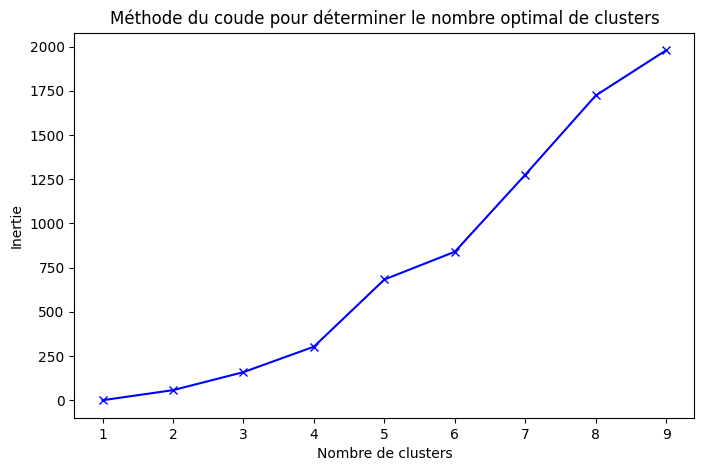

In [113]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances_argmin_min
# Fonction pour calculer l'inertie
def compute_inertia(X, labels, centers):
    distances, _ = pairwise_distances_argmin_min(X, centers)
    inertia = np.sum(distances ** 2)
    return inertia

# Calculer les inerties pour différents nombres de clusters
inertias = []
K = range(1, 10)
for k in K:
    model = AgglomerativeClustering(n_clusters=k)
    labels = model.fit_predict(data1_norm)
    centers = np.array([data1_norm[labels == i].mean(axis=0) for i in range(k)])
    inertia = compute_inertia(data1_norm, labels, centers)
    inertias.append(inertia)

# Tracer la courbe du coude
plt.figure(figsize=(8, 5))
plt.plot(K, inertias, 'bx-')
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertie')
plt.title('Méthode du coude pour déterminer le nombre optimal de clusters')
plt.show()

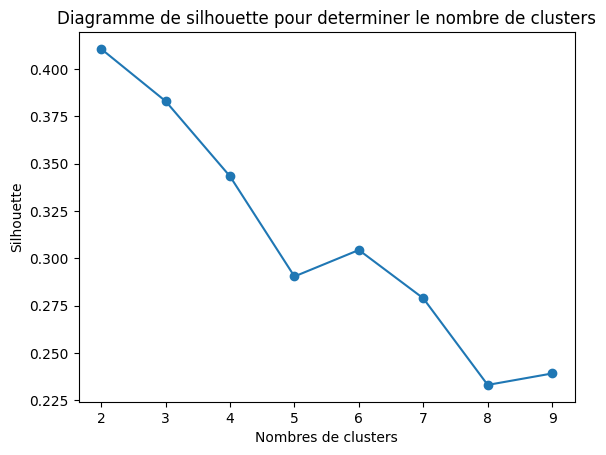

In [114]:
silhouettes_CAH = []
for i in range(2, 10):
    km = AgglomerativeClustering(n_clusters=i)
    km.fit(data1_norm)
    silhouettes_CAH.append(silhouette_score(data1_norm, km.labels_))
plt.plot(range(2, 10), silhouettes_CAH, marker='o')
plt.xlabel("Nombres de clusters")
plt.ylabel("Silhouette")
plt.title("Diagramme de silhouette pour determiner le nombre de clusters")
plt.show()

In [115]:

# mise en place du modele
cah = AgglomerativeClustering(n_clusters=5)
labels_predict = cah.fit_predict(data1_norm)
data['zones'] = labels_predict
data.head()

,Area,Population_Density,Household_Size,Waste_Generation,Collection_Frequency,Recycling_Rate,Collection_Point_Location,Road_Network_Score,Disposal_Site_Distance,Pollution_Level,Top 1 Waste_Type,Top 2 Waste_Type,Top 3 Waste_Type,cluster,zones
0,Quartier_1,8270.0,6,3.39,6,0.35,53,0.98,2.13,0.72,Paper,Plastic,Glass,0,1
1,Quartier_2,1860.0,4,2.31,2,0.74,40,0.49,17.95,0.31,Paper,Metal,Glass,1,4
2,Quartier_3,6390.0,5,1.20,2,0.69,53,0.72,4.62,0.47,Glass,Organic,Paper,1,0
3,Quartier_4,6191.0,6,0.56,3,0.85,74,0.82,2.38,0.20,Glass,Metal,Organic,1,0
4,Quartier_5,6734.0,5,2.11,1,0.62,52,0.72,2.46,0.48,Organic,Plastic,Glass,1,0


In [116]:
for cluster in range(5):
    zones_cluster = data[data['zones'] == cluster]['Area'].tolist()
    print(f"Zones appartenent au cluster {cluster}: {', '.join(zones_cluster)}")

Zones appartenent au cluster 0: Quartier_3, Quartier_4, Quartier_5, Quartier_8, Quartier_9, Quartier_16, Quartier_19, Quartier_30, Quartier_45, Quartier_58, Quartier_60, Quartier_71, Quartier_77, Quartier_85, Quartier_86, Quartier_89, Quartier_101, Quartier_111, Quartier_112, Quartier_121, Quartier_129, Quartier_133, Quartier_136, Quartier_138, Quartier_142
Zones appartenent au cluster 1: Quartier_1, Quartier_6, Quartier_10, Quartier_13, Quartier_15, Quartier_21, Quartier_24, Quartier_37, Quartier_39, Quartier_40, Quartier_43, Quartier_44, Quartier_46, Quartier_48, Quartier_56, Quartier_57, Quartier_62, Quartier_64, Quartier_67, Quartier_72, Quartier_73, Quartier_74, Quartier_75, Quartier_76, Quartier_80, Quartier_82, Quartier_93, Quartier_94, Quartier_98, Quartier_100, Quartier_102, Quartier_105, Quartier_116, Quartier_119, Quartier_122, Quartier_124, Quartier_139, Quartier_141
Zones appartenent au cluster 2: Quartier_11, Quartier_12, Quartier_18, Quartier_25, Quartier_27, Quartier_28

In [117]:
def compute_inertia(X, labels, centers):
    distances, _ = pairwise_distances_argmin_min(X, centers)
    inertia = np.sum(distances ** 2)
    return inertia

centers = np.array([data1_norm[labels_predict == i].mean(axis=0) for i in range(2)])

compute_inertia(data1_norm, labels_predict, centers)

54

In [118]:
s = silhouette_score(data1_norm, labels_predict)
s

0.2903555739813125

# Algorithme DBSCAN

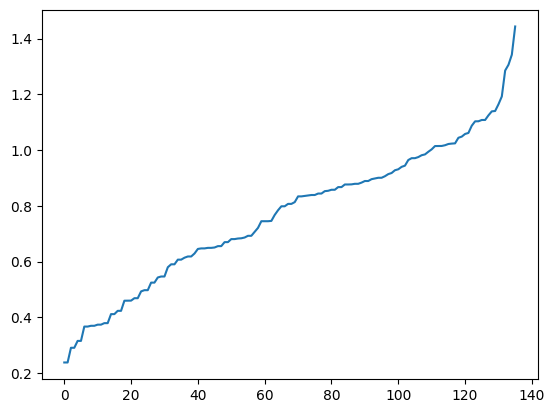

In [119]:
%matplotlib inline
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

voisins = NearestNeighbors(n_neighbors=2)
nbrs = voisins.fit(data1_norm)
distances, indices = nbrs.kneighbors(data1_norm)
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.plot(distances)

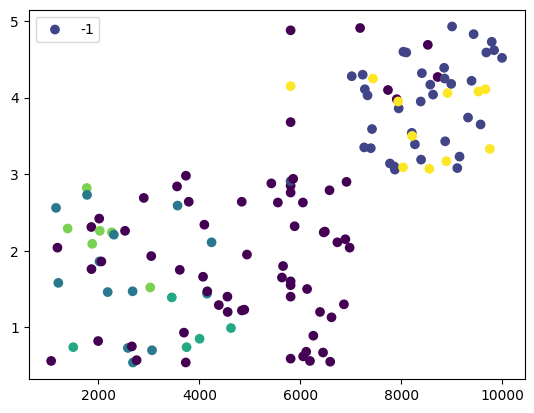

In [120]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

y_pred = DBSCAN(eps=1.0, min_samples=5).fit_predict(data1_norm)

plt.scatter(data1['Population_Density'], data1['Waste_Generation'], c=y_pred)

labels = np.unique(y_pred)

plt.legend(labels)

# Identification des sites de décharge illégale

Les décharges illégales posent un danger 
environnemental  et  sanitaire  important.  Malgré  nos  efforts,  elles  continuent  d'être  un 
problème persistant dans certaines zones. Nous avons besoin d'un système capable de 
détecter  automatiquement  les  sites  de  décharge  illégale  en  identifiant  des  schémas 
inhabituels dans les données de gestion des déchets. Cela nous permettra de prendre des 
mesures  rapides  pour  prévenir  et  résoudre  les  décharges  illégales,  protégeant  ainsi 
l'environnement et la santé publique.

In [121]:
from sklearn.ensemble import IsolationForest

data = data.drop(['Area', 'Top 1 Waste_Type', 'Top 2 Waste_Type', 'Top 3 Waste_Type'], axis=1)

modele_sites_illegales = IsolationForest(contamination=0.05, random_state=42)
modele_sites_illegales.fit(data)

IsolationForest(contamination=0.05, random_state=42)

In [122]:
data['Anomalie'] = modele_sites_illegales.predict(data)

data['Anomalie'] = data['Anomalie'].map({1: 'Normal', -1: 'Anomalie'})
data.head()

,Population_Density,Household_Size,Waste_Generation,Collection_Frequency,Recycling_Rate,Collection_Point_Location,Road_Network_Score,Disposal_Site_Distance,Pollution_Level,cluster,zones,Anomalie
0,8270.0,6,3.39,6,0.35,53,0.98,2.13,0.72,0,1,Normal
1,1860.0,4,2.31,2,0.74,40,0.49,17.95,0.31,1,4,Normal
2,6390.0,5,1.20,2,0.69,53,0.72,4.62,0.47,1,0,Normal
3,6191.0,6,0.56,3,0.85,74,0.82,2.38,0.20,1,0,Normal
4,6734.0,5,2.11,1,0.62,52,0.72,2.46,0.48,1,0,Normal
